<a href="https://colab.research.google.com/github/gandlurianitha/DataScience/blob/Projects/Porter_Neural_Networks_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Porter: Neural Networks Regression**

**1. Problem statement :**
Predict food delivery time based on the order, restaurant , and delivery partner information. It is a supervised regression problem.

This is a Supervised Regression Problem because:

Input = Order details + Restaurant + Delivery partner information

Output = Delivery Time


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/data_2.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/data_2.csv'

In [ ]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [ ]:
df.shape

(175777, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

In [ ]:
df.describe()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
count,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000
mean,2.743726,35.887949,2.911752,3.204976,2697.111147,2.675060,684.965433,1160.158616,44.918664,41.861381,58.230115,546.077240
std,1.330963,20.728254,1.513128,2.674055,1828.554893,1.625681,519.882924,560.828571,34.544724,32.168505,52.731043,218.717798
min,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000
25%,2.000000,18.000000,1.000000,2.000000,1412.000000,1.000000,299.000000,799.000000,17.000000,15.000000,17.000000,384.000000
50%,2.000000,38.000000,3.000000,3.000000,2224.000000,2.000000,595.000000,1095.000000,37.000000,35.000000,41.000000,544.000000
75%,4.000000,55.000000,4.000000,4.000000,3410.000000,3.000000,942.000000,1395.000000,66.000000,63.000000,85.000000,703.000000
max,6.000000,72.000000,7.000000,411.000000,26800.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2088.000000


In [ ]:
df.isnull().sum()

,0
market_id,0
created_at,0
actual_delivery_time,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0


In [ ]:
df["created_at"] = pd.to_datetime(df["created_at"])

In [ ]:
df["actual_delivery_time"] = pd.to_datetime(df["actual_delivery_time"])

In [ ]:
df["delivery_time"] = (df["actual_delivery_time"]-df["created_at"]).dt.total_seconds()/60

In [ ]:
df["order_hour"] = df["created_at"].dt.hour

In [ ]:
df["day"] = df["created_at"].dt.dayofweek

In [ ]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_time,order_hour,day
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47.0,22,4
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44.0,21,1
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55.0,0,0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59.0,3,3
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46.0,2,1


In [ ]:
df.drop(["created_at","actual_delivery_time"],axis=1,inplace=True)

In [ ]:
df.head()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_time,order_hour,day
0,1.0,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47.0,22,4
1,2.0,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44.0,21,1
2,2.0,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55.0,0,0
3,1.0,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59.0,3,3
4,1.0,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46.0,2,1


In [ ]:
df.isnull().sum()

,0
market_id,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0
total_onshift_dashers,0
total_busy_dashers,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["day"] = le.fit_transform(df["day"])

In [ ]:
df["store_primary_category"] = le.fit_transform(df["store_primary_category"])

In [ ]:
df.head()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_time,order_hour,day
0,1.0,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47.0,22,4
1,2.0,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44.0,21,1
2,2.0,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55.0,0,0
3,1.0,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59.0,3,3
4,1.0,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46.0,2,1


<Axes: xlabel='delivery_time', ylabel='Count'>

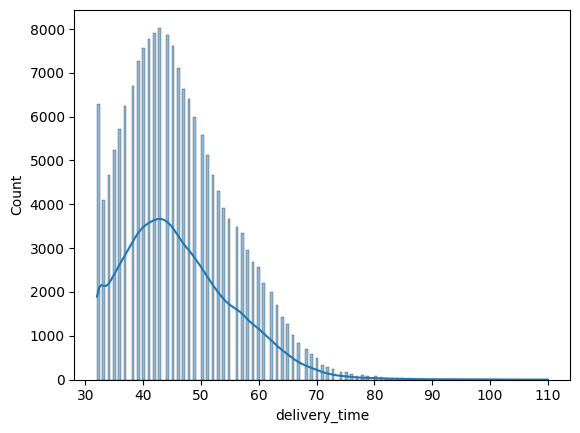

In [ ]:
sns.histplot(df["delivery_time"], kde=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<Axes: xlabel='order_hour', ylabel='count'>

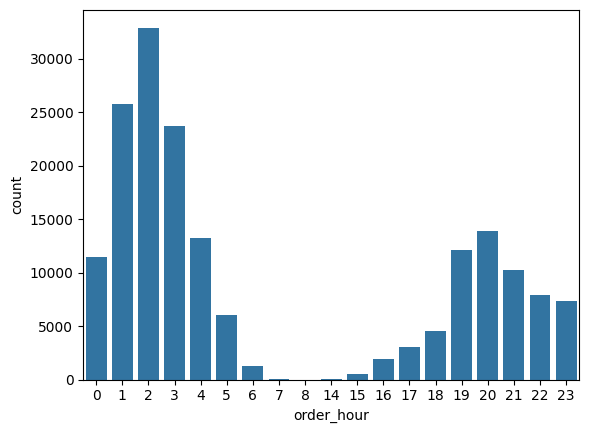

In [ ]:
sns.countplot(x="order_hour",data=df)

<Axes: xlabel='subtotal', ylabel='delivery_time'>

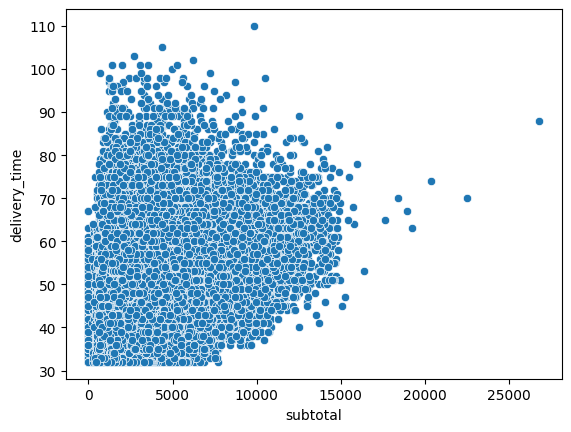

In [ ]:
sns.scatterplot(x="subtotal",y="delivery_time",data=df)

<Axes: >

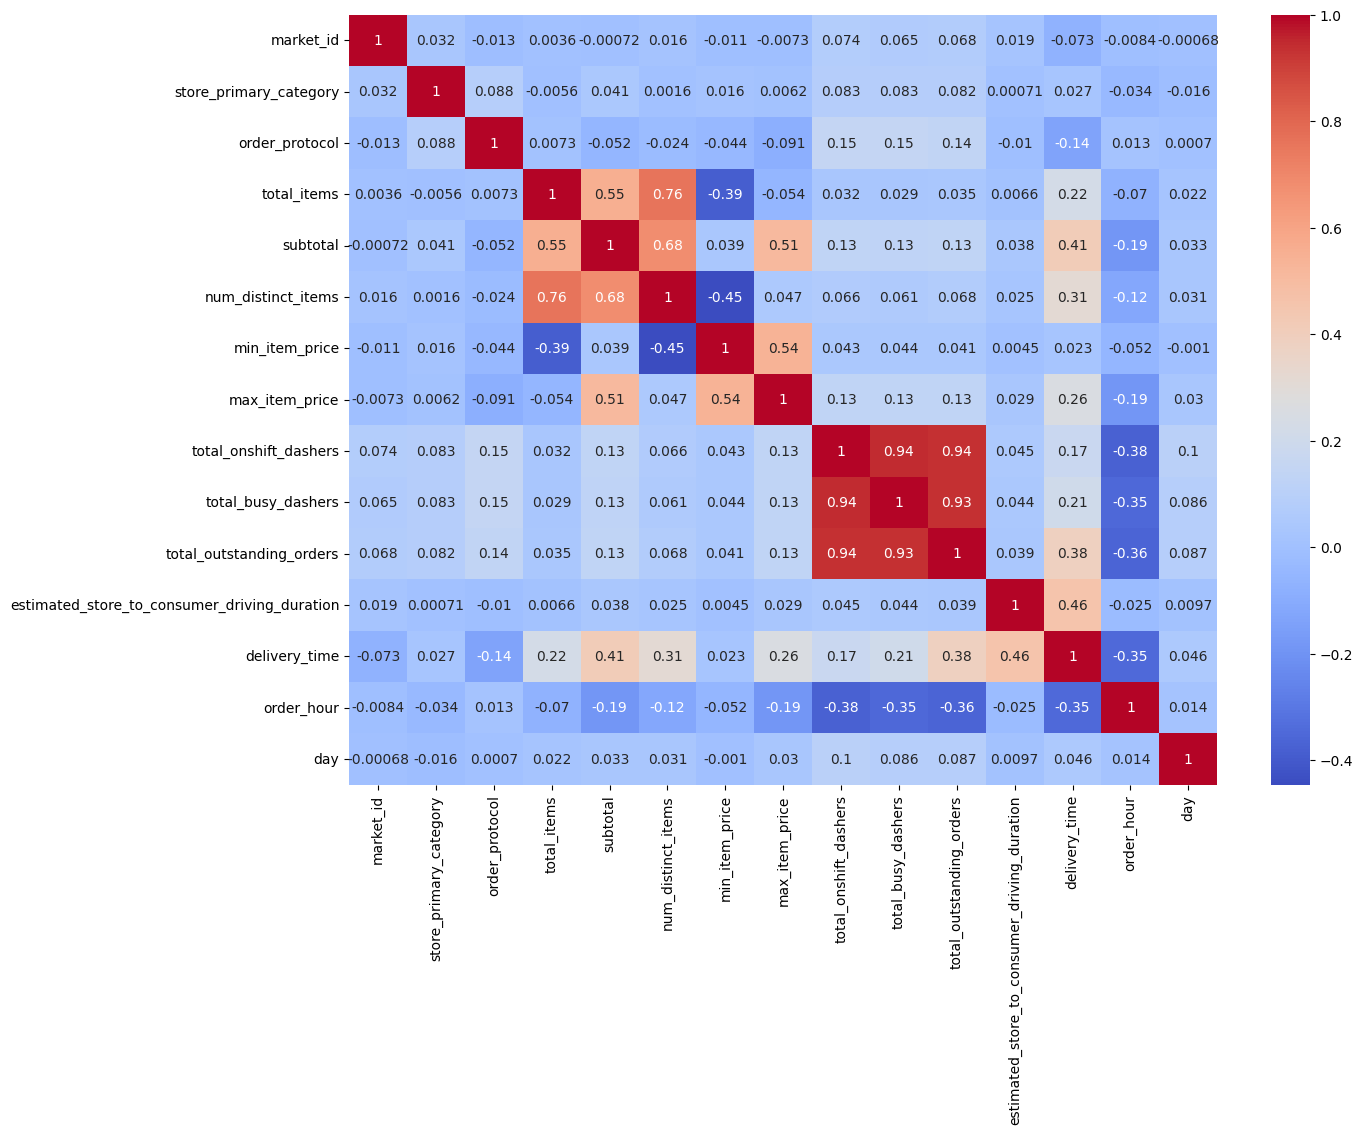

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

<Axes: ylabel='delivery_time'>

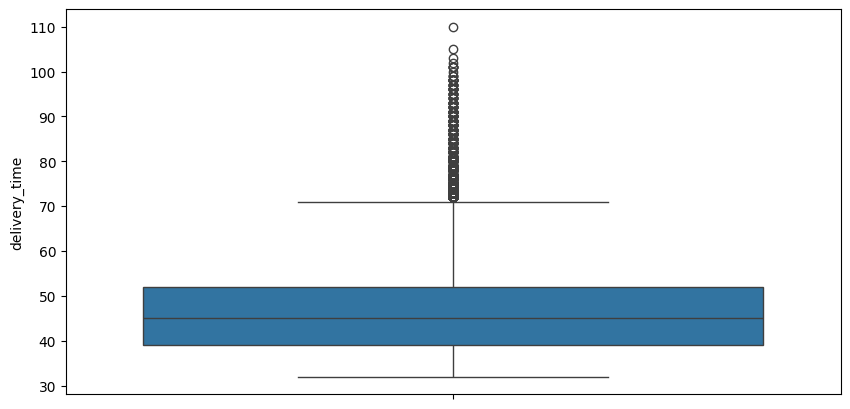

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(df["delivery_time"])

In [ ]:
Q1=df["delivery_time"].quantile(0.25)

Q3=df["delivery_time"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

df=df[
(df.delivery_time>=lower)
&
(df.delivery_time<=upper)
]

<Axes: ylabel='delivery_time'>

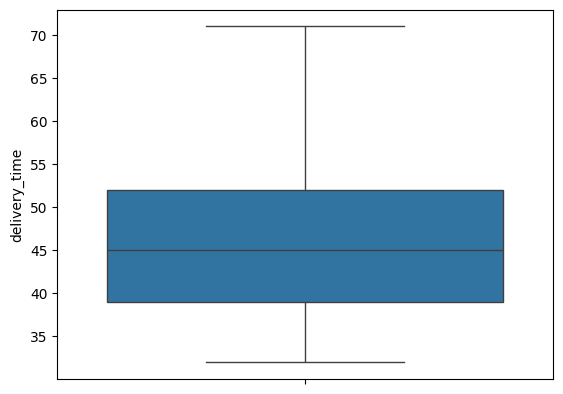

In [ ]:
sns.boxplot(df["delivery_time"])

In [ ]:
X=df.drop("delivery_time",axis=1)

y=df["delivery_time"]
print(X.shape)
print(y.shape)

(174028, 14)
(174028,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
pred=rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
print(np.sqrt(mean_squared_error(y_test,pred)))

In [ ]:
print(mean_absolute_error(y_test,pred))

In [ ]:
print(r2_score(y_test,pred))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model=Sequential()

model.add(Dense(128,activation="relu",input_shape=(X_train.shape[1],)))

model.add(Dropout(0.3))
model.add(Dense(64,activation="relu"))
model.add(Dense(32,activation="relu"))
model.add(Dense(1))

In [ ]:
model.compile(optimizer="adam",loss="mse",metrics=["mae"])

In [ ]:
history=model.fit(X_train,y_train,validation_split=0.2,epochs=50,
batch_size=256,callbacks=[EarlyStopping(patience=5,restore_best_weights=True)])

In [ ]:
plt.plot(history.history["loss"])

In [ ]:
plt.plot(history.history["val_loss"])

In [ ]:
plt.legend(["Train","Validation"])

In [ ]:
prediction=model.predict(X_test)

In [ ]:
rmse=np.sqrt(mean_squared_error(y_test,prediction))
mae=mean_absolute_error(y_test,prediction)
print(rmse)
print(mae)

**Testing the model for prediction**

In [ ]:
sample1 = {'market_id': 1,
    'store_primary_category': 'Indian',
    'order_protocol': 2,
    'total_items': 5,
    'subtotal': 950,
    'num_distinct_items': 4,
    'min_item_price': 120,
    'max_item_price': 350,
    'total_onshift_partners': 60,
    'total_busy_partners': 55,
    'total_outstanding_orders': 42,
    'estimated_store_to_consumer_driving_duration': 18,
    'order_hour': 13,
    'day_of_week': 'Monday'
}

In [ ]:
sample_df = pd.DataFrame([sample1])
sample_df = pd.get_dummies(sample_df)

sample_df = sample_df.reindex(columns=X.columns, fill_value=0)
prediction = rf.predict(sample_df)

print(f"Estimated Delivery Time: {prediction[0]:.2f} minutes")

**Questions in the business case:**

**1. Defining the problem statements and where can this and modifications of this be used?**

Predict food delivery time using order, restaurant, and delivery partner information. It is a supervised regression problem.

**2. List 3 functions the pandas datetime provides with one line explanation.**

.dt.hour → Extract hour from timestamp.

.dt.day_name() → Returns weekday name.

.dt.total_seconds() → Converts a time difference into seconds.

**3. Short note on datetime, timedelta, time span (period)**

Datetime: Represents a specific date and time.

Timedelta: Represents the duration between two dates/times.

Period (Time Span): Represents a fixed interval such as a month, quarter, or year.

**4. Why do we need to check for outliers in our data?**
Outliers can:

Distort model training

Increase prediction error

Reduce model generalization

Affect evaluation metrics

**5. Name 3 outlier removal methods?**

IQR Method

Z-Score Method

Isolation Forest

**6. What classical machine learning methods can we use for this problem?**

Linear Regression

Decision Tree Regressor

Random Forest Regressor

Gradient Boosting

XGBoost

LightGBM

SVR

**7.Why is scaling required for neural networks?**

Speeds up convergence

Prevents exploding/vanishing gradients

Improves optimizer performance

Makes feature magnitudes comparable

**8.Briefly explain your choice of optimizer.**

Adam was chosen because it:

Combines Momentum and RMSProp

Adapts learning rates automatically

Converges faster

Is robust for large datasets

**9. Which activation function did you use and why?**
ReLU for hidden layers because it:

Reduces the vanishing gradient problem

Is computationally efficient

Enables sparse activations

Trains faster than sigmoid or tanh


The output layer uses a linear activation (default) because this is a regression task.

**10. Why does a neural network perform well on a large dataset?**

Learn complex non-linear relationships

Automatically extract useful feature interactions

Scale effectively with more data

Capture patterns that simpler models may miss